In [154]:
import nltk  # Biblioteca usada para o processamento de linguagem natural
import spacy  # Biblioteca para processamento de linguagem natural e análise de texto
import pandas as pd  # Biblioteca para manipulação e análise de dados estruturados
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos e visualizações
from wordcloud import WordCloud  # Biblioteca para gerar nuvens de palavras a partir de textos
from collections import Counter  # Biblioteca para contagem de elementos em iteráveis, útil para análise de frequência
from nltk.corpus import stopwords  # Módulo do NLTK que fornece uma lista de palavras comuns a serem ignoradas (stop words)
import re  # Biblioteca para manipulação e busca de padrões em strings usando expressões regulares
import unicodedata

In [155]:
# Download necessário para a NLTK
nltk.download('stopwords')  # Baixa a lista de stop words (palavras comuns) para uso no processamento de texto
nltk.download('punkt')  # Baixa o tokenizer Punkt, necessário para a tokenização de frases

# Carregar o modelo de português para o spaCy
!python -m spacy download pt_core_news_sm

[nltk_data] Downloading package stopwords to /home/marcos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/marcos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 24.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [156]:
data = pd.read_csv('../dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')

/tmp/ipykernel_9493/1259012095.py:1: DtypeWarning: Columns (6,11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')


In [157]:
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,categoria
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia


In [158]:
def remove_noise(text):

    # Converte para minúsculas
    text = text.lower()

    # Remove URLs
    # S+: corresponde a um ou mais caracteres que não são espaços em branco (o \S significa “qualquer caractere que não seja espaço em branco” e o + indica que deve haver um ou mais desses caracteres)
    text = re.sub(r'http\S+', '', text)

    # Remove menções e hashtags
    # @: corresponde ao caractere “@” usado para menções.
    # #: corresponde ao caractere “#” usado para hashtags.
    # |: operador “ou” que permite combinar dois padrões.
    # \w+: corresponde a um ou mais caracteres alfanuméricos (inclui letras e números).
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remoce acentos
    nfkd_form = unicodedata.normalize('NFD', text)
    text = "".join([c for c in nfkd_form if not unicodedata.combining(c)])

    # Remove pontuação
    # []: colchetes são usados para definir uma classe de caracteres.
    # ^: quando usado no início de uma classe de caracteres, o ^ nega a classe, ou seja, seleciona tudo que não está na classe.
    # \w: corresponde a qualquer caractere alfanumérico (letras e números, incluindo o caractere de sublinhado _)
    # \s: corresponde a qualquer espaço em branco (espaços, tabulações, quebras de linha).
    text = re.sub(r'[^\w\s]', '', text)

    # Remove números
    # \d: corresponde a qualquer dígito (de 0 a 9).
    # +: significa “um ou mais” do elemento precedente. Portanto, \d+ corresponde a uma sequência de um ou mais dígitos consecutivos.
    text = re.sub(r'\d+', '', text)

    return text

In [159]:
def remove_stopwords(text):
  # Obtém a lista de stopwords em português usando o NLTK e as converte para um conjunto para melhorar a eficiência da busca
  stop_words = set(stopwords.words('portuguese'))

  custom_stop_words = set(['analise', 'estudo', 'sobre', 'avaliacao', 'rio', 'grande', 'norte', 'municipio',
                           'natalrn', 'processo', 'brasil', 'sistema','caso','rn','uso','natal','trabalho',
                           'revisao','aplicacao','influencia','partir', 'ufrn', 'atencao', 'experiencia',
                           'efeito', 'contexto', 'importancia', 'apresentado'])

  # --- 4. COMBINAR AS DUAS LISTAS ---
  # .union() junta os dois conjuntos
  final_stop_words = stop_words.union(custom_stop_words)

  # Divide o texto em palavras, remove as stopwords e então junta as palavras restantes de volta em uma string
  text = ' '.join([word for word in text.split() if word not in final_stop_words])

  return text

In [160]:
# Aplicando a remoção de ruído
data['titulo2'] = data['titulo'].apply(remove_noise)
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,categoria,titulo2
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,explorando o potencial das financas verdes uma...
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,indicadores de desempenho um estudo da perspec...
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,analise e influencia do clima organizacional n...
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,compras por impulso online em plataformas de m...
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,inteligencia artificial no futebol uma revisao...


In [161]:
# Aplicando a remoção de stopwords
data['titulo3'] = data['titulo2'].apply(remove_stopwords)
data.head()

,titulo,nome_orientador,nivel,ano,classificacao,unidade,palavras_chave,data_inicio,data_fim,situacao,tipo_projeto,linha_pesquisa,categoria,titulo2,titulo3
0,explorando o potencial das finanças verdes: um...,israel josé dos santos felipe,graduação,2024.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/11/25 00:00:00.000,2025/11/25 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,explorando o potencial das financas verdes uma...,explorando potencial financas verdes revisaona...
1,indicadores de desempenho: um estudo da perspe...,marconi neves macedo,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/09/09 00:00:00.000,2025/09/09 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,indicadores de desempenho um estudo da perspec...,indicadores desempenho perspectiva orcamentari...
2,análise e influência do clima organizacional n...,antonio carlos ferreira,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,analise e influencia do clima organizacional n...,clima organizacional satisfacao colaboradores ...
3,compras por impulso online em plataformas de m...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,compras por impulso online em plataformas de m...,compras impulso online plataformas marketplace...
4,inteligência artificial no futebol: uma revisã...,anatalia saraiva martins ramos,graduação,2025.0,tcc,CENTRO DE CIÊNCIAS SOCIAIS APLICADAS,NaN,2025/07/24 00:00:00.000,2025/07/24 00:00:00.000,FINALIZADO,INTERNO,NaN,monografia,inteligencia artificial no futebol uma revisao...,inteligencia artificial futebol escopo


In [162]:
nlp = spacy.load('pt_core_news_sm')

In [163]:
# Cria uma lista de palavras, iterando por cada avaluiação em 'clean_review', dividindo cada resenha em palavras
words = [word for review in data['titulo3'] for word in review.split()]
# Conta a frequência de cada palavra na lista 'words' usando a função Counter da biblioteca collections, criando um dicionário onde as chaves são palavras e os valores são suas frequências
word_freq = Counter(words)
# Obtém as 10 palavras mais comuns e suas frequências, retornando uma lista de tuplas onde cada tupla contém uma palavra e sua contagem
most_common_words = word_freq.most_common(10)
# Imprime a lista das 10 palavras mais comuns e suas respectivas frequências
print('Palavras mais comuns:', most_common_words)

Palavras mais comuns: [('saude', 7371), ('educacao', 4993), ('ensino', 4492), ('desenvolvimento', 3499), ('gestao', 2678), ('qualidade', 2274), ('estado', 2241), ('social', 2151), ('hospital', 2135), ('pacientes', 2049)]


In [164]:
from tqdm import tqdm
tqdm.pandas()

In [165]:
# !pip install pandarallel
from pandarallel import pandarallel # import pandarallel
pandarallel.initialize(progress_bar=True) # initialize pandarallel

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [166]:
def tokenize_text(text):
    doc = nlp(text)
    tokens = [token.text for token in doc]
    return tokens

# data['tokens'] = data['titulo3'].apply(tokenize_text)
# data['tokens'] = data['titulo3'].progress_apply(tokenize_text)
data['tokens'] = data['titulo3'].parallel_apply(tokenize_text)

In [167]:
tokens = [token for review in data['tokens'] for token in review]
token_freq = Counter(tokens)
most_common_tokens = token_freq.most_common(30)
print('Tokens mais comuns:', most_common_tokens)

Tokens mais comuns: [('saude', 7371), ('educacao', 4993), ('ensino', 4492), ('desenvolvimento', 3500), ('gestao', 2678), ('qualidade', 2274), ('estado', 2241), ('social', 2151), ('hospital', 2135), ('pacientes', 2049), ('escola', 2035), ('projeto', 2010), ('formacao', 1900), ('cidade', 1893), ('proposta', 1854), ('producao', 1850), ('caracterizacao', 1817), ('criancas', 1670), ('infantil', 1653), ('vida', 1642), ('unidade', 1610), ('direito', 1546), ('controle', 1525), ('programa', 1499), ('publica', 1497), ('construcao', 1475), ('tratamento', 1396), ('federal', 1387), ('implantacao', 1368), ('praticas', 1359)]


In [168]:
tokens_por_ano = data.groupby('ano')['tokens'].sum()
tokens_mais_comuns_por_ano = tokens_por_ano.apply(
    lambda all_tokens_do_ano: Counter(all_tokens_do_ano).most_common(5)
)

print('Tokens mais comuns por ano:', tokens_mais_comuns_por_ano)

Tokens mais comuns por ano: ano
1988.0         [(exportacao, 1), (lagosta, 1), (estado, 1)]
1990.0    [(descritiva, 1), (criminalidade, 1), (vivenci...
1992.0    [(universidade, 2), (comunidadeum, 1), (projet...
1993.0    [(habitacao, 1), (iniciativa, 1), (popular, 1)...
1994.0    [(revitalizacao, 1), (preservacao, 1), (avenid...
1995.0    [(proposta, 3), (arquitetonica, 1), (escolas, ...
1996.0    [(infeccoes, 2), (cirurgias, 2), (abdominais, ...
1997.0    [(pousada, 2), (plano, 2), (projeto, 2), (exte...
1998.0    [(memorial, 1), (cidade, 1), (anos, 1), (igrej...
1999.0    [(fisica, 3), (educacao, 2), (visao, 2), (epoc...
2000.0    [(caracterizacao, 31), (desenvolvimento, 19), ...
2001.0    [(parte, 21), (ii, 19), (novos, 11), (desenvol...
2002.0    [(caracterizacao, 21), (saude, 20), (parte, 19...
2003.0    [(petroleo, 22), (desenvolvimento, 20), (proje...
2004.0    [(saude, 21), (caracterizacao, 21), (desenvolv...
2005.0    [(saude, 31), (cidade, 24), (educacao, 24), (d...
2006.0  

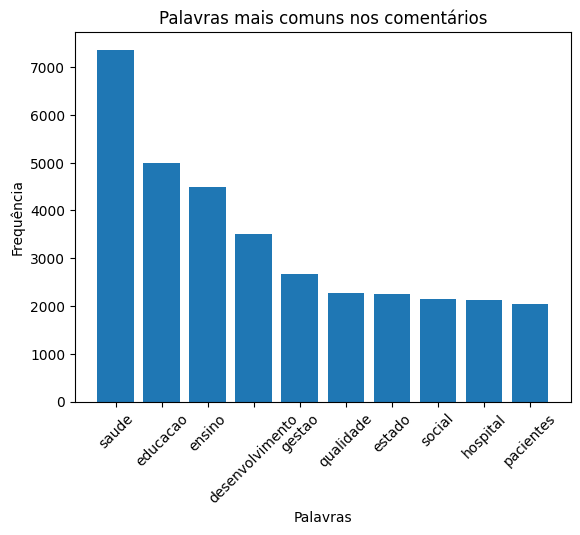

In [169]:
# Visualizando as palavras mais comuns
words, counts = zip(*most_common_words)
plt.bar(words, counts)
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.title('Palavras mais comuns nos comentários')
plt.show()

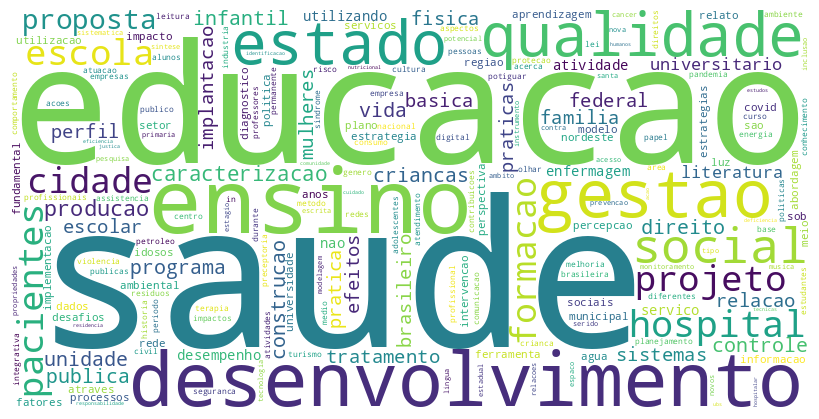

In [170]:
# Gerando uma nuvem de palavras a partir da frequência das palavras depois de tratado
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

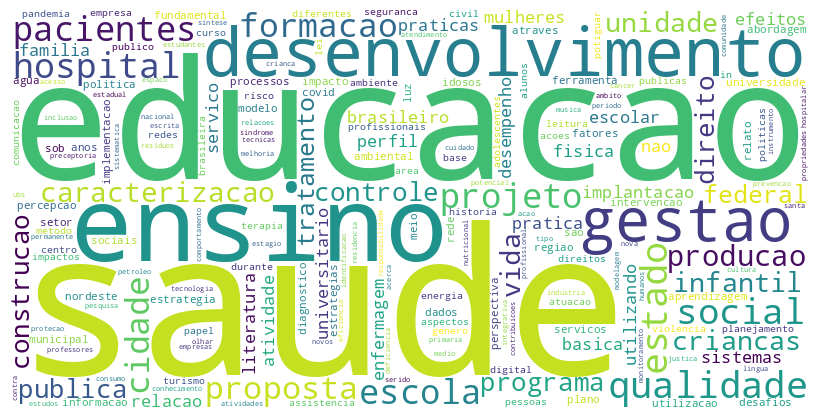

In [171]:
# Gerando uma nuvem de palavras a partir da frequência dos tokens
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(token_freq)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

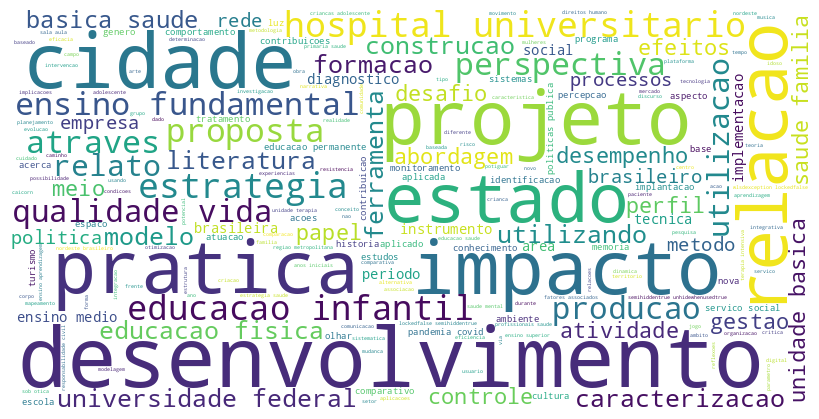

In [172]:
# Gerando uma nuvem de palavras a partir do texto deixando o WordCloud gerar as palavras
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate(' '.join(data['titulo3']))
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

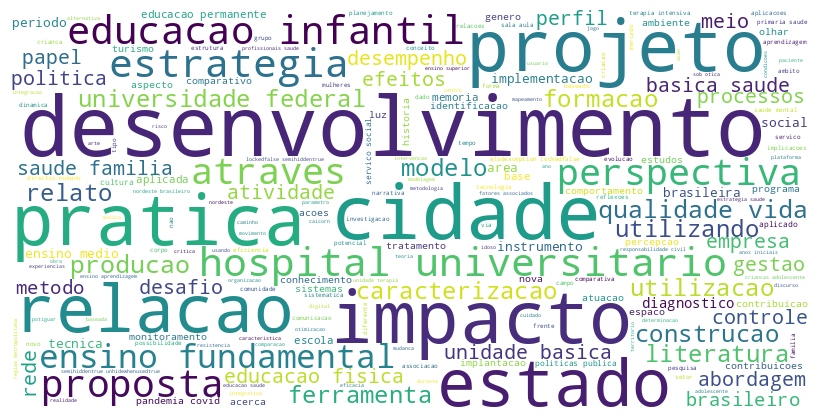

In [173]:
# Gerando uma nuvem de palavras a partir dos tokens deixando o WordCloud gerar as palavras
wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate(' '.join(tokens))
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()